In [1]:
!pip install gensim gradio contractions nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import contractions
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import gensim.downloader as api
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

2026-05-09 18:05:12.975310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778349913.308917      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778349913.397624      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778349914.091351      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778349914.091409      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778349914.091412      57 computation_placer.cc:177] computation placer alr

True

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sujentamang/hatespeech-dataset/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv', encoding='utf-8')
# If columns have different names, rename them
# df = df.rename(columns={'tweet': 'text', 'class': 'label'})

print(df['label'].value_counts())

label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Lemmatize and remove stopwords
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

# Show sample
print(df[['text', 'clean_text']].head())

                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                          clean_text  
0  rt woman complain cleaning house amp man alway...  
1  rt boy dat coldtyga dwn bad cuffin dat hoe st ...  
2  rt dawg rt ever fuck bitch start cry confused ...  
3                                rt look like tranny  
4  rt shit hear might true might faker bitch told ya  


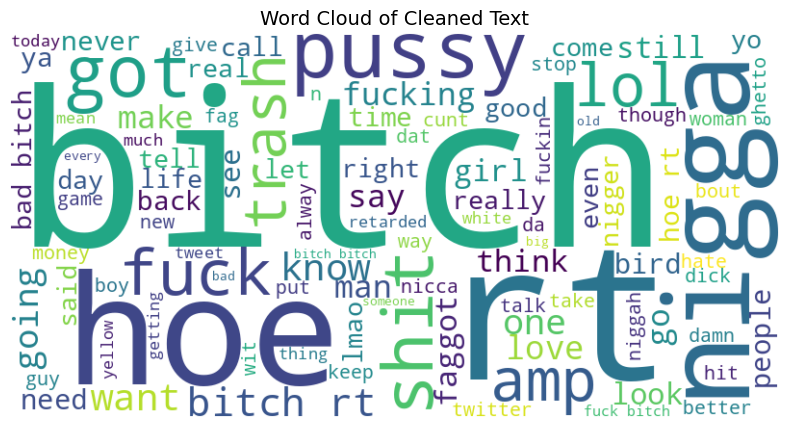

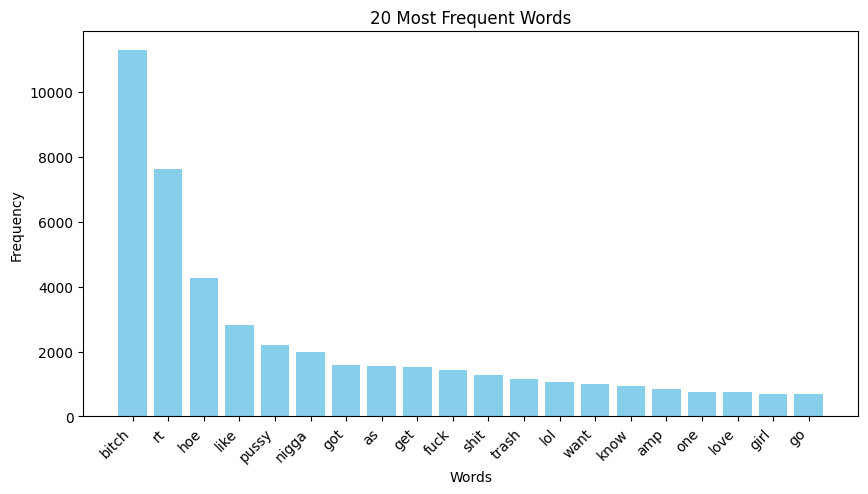

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text
all_text = ' '.join(df['clean_text'].tolist())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text', fontsize=14)
plt.show()

# Most frequent words (using Counter)
from collections import Counter

words = all_text.split()
word_counts = Counter(words)
common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [10]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(3)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}


In [15]:
print("Unique labels in dataset:", set(y_train))

Unique labels in dataset: {'offensive language', 'hate speec', 'neither'}


In [16]:
# Map string labels to integers
label_mapping = {'hate speec': 0, 'offensive language': 1, 'neither': 2}
# Or whatever your actual labels are. Check unique values:
print(y_train[:5])  # to see the format

# Convert to integers
y_train_int = np.array([label_mapping[label] for label in y_train])
y_test_int = np.array([label_mapping[label] for label in y_test])

# Now convert to categorical
y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

['offensive language' 'hate speec' 'offensive language'
 'offensive language' 'offensive language']


In [21]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

In [23]:
# ============================================
# STEP 5: Convert labels to integers, then to categorical
# ============================================

# 5.1 Check unique labels (if you haven't already)
print("Unique labels:", set(y_train))

# 5.2 Create mapping with EXACT strings from your dataset
# Based on your error output, the labels are:
#   'hate speec' (note the missing 'h')
#   'offensive language'
#   'neither' (I assume present; if not, adjust)
label_mapping = {
    'hate speec': 0,
    'offensive language': 1,
    'neither': 2
}

# 5.3 Convert y_train and y_test to integer arrays
y_train_int = np.array([label_mapping[label] for label in y_train])
y_test_int = np.array([label_mapping[label] for label in y_test])

# 5.4 Verify conversion
print("Sample integer labels:", y_train_int[:10])
print("Unique integer labels:", set(y_train_int))

# 5.5 Now convert to one‑hot categorical (3 classes)
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

print("Shape of y_train_cat:", y_train_cat.shape)  # should be (n_samples, 3)

Unique labels: {'offensive language', 'hate speec', 'neither'}
Sample integer labels: [1 0 1 1 1 1 1 1 1 2]
Unique integer labels: {np.int64(0), np.int64(1), np.int64(2)}
Shape of y_train_cat: (19826, 3)


In [39]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Define class weights
class_weight_dict = {
    0: 5.0,   # hate speech
    1: 0.5,   # offensive language
    2: 1.0    # neither
}
print("Class weights:", class_weight_dict)

Class weights: {0: 5.0, 1: 0.5, 2: 1.0}


In [40]:
embedding_dim = 100

rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5899 - loss: 0.8657 - val_accuracy: 0.8084 - val_loss: 0.5583
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7788 - loss: 0.6508 - val_accuracy: 0.8129 - val_loss: 0.6010
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7925 - loss: 0.5411 - val_accuracy: 0.8290 - val_loss: 0.4910
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8494 - loss: 0.4243 - val_accuracy: 0.8555 - val_loss: 0.4332
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8799 - loss: 0.3543 - val_accuracy: 0.8374 - val_loss: 0.5001
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8985 - loss: 0.2820 - val_accuracy: 0.7968 - val_loss: 0.5899
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9042 - loss: 0.2664 - val_accuracy: 0.8354 - val_loss: 0.5033


In [41]:
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7706 - loss: 0.7613 - val_accuracy: 0.8187 - val_loss: 0.4537
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8397 - loss: 0.4318 - val_accuracy: 0.8306 - val_loss: 0.4744
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8660 - loss: 0.3294 - val_accuracy: 0.8442 - val_loss: 0.4400
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8969 - loss: 0.2605 - val_accuracy: 0.8018 - val_loss: 0.5188
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9273 - loss: 0.1942 - val_accuracy: 0.8510 - val_loss: 0.4385
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9314 - loss: 0.1688 - val_accuracy: 0.8169 - val_loss: 0.4929
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9476 - loss: 0.1271 - val_accuracy: 0.8396 - val_loss: 0.4785
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9487 - loss: 0.1265 - val_acc

In [42]:
print("Loading Word2Vec model (glove-wiki-gigaword-50)...")
word2vec_model = api.load('glove-wiki-gigaword-50')   # 50-dim
embedding_dim_w2v = 50

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        try:
            embedding_matrix[i] = word2vec_model[word]
        except KeyError:
            pass

lstm_w2v = Sequential([
    Embedding(vocab_size, embedding_dim_w2v, weights=[embedding_matrix], input_length=max_len, trainable=False),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

lstm_w2v.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_w2v.summary()

history_w2v = lstm_w2v.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Loading Word2Vec model (glove-wiki-gigaword-50)...


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6862 - loss: 0.8311 - val_accuracy: 0.7905 - val_loss: 0.6147
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7405 - loss: 0.6428 - val_accuracy: 0.8348 - val_loss: 0.4697
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7509 - loss: 0.5984 - val_accuracy: 0.8376 - val_loss: 0.4797
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7822 - loss: 0.5629 - val_accuracy: 0.8197 - val_loss: 0.4937
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7859 - loss: 0.5489 - val_accuracy: 0.8290 - val_loss: 0.4523
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7741 - loss: 0.5639 - val_accuracy: 0.8205 - val_loss: 0.4810
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7870 - loss: 0.5266 - val_accuracy: 0.8197 - val_loss: 0.4799
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7916 - loss: 0.5153 - val_accu

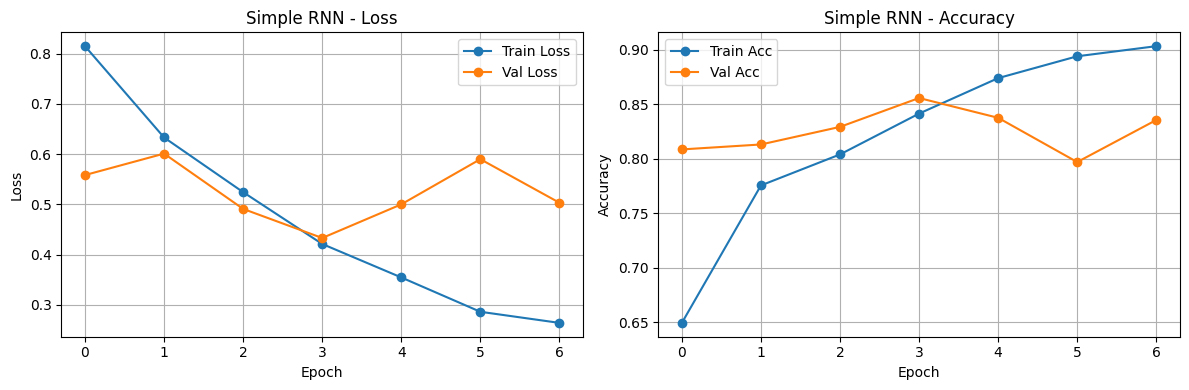

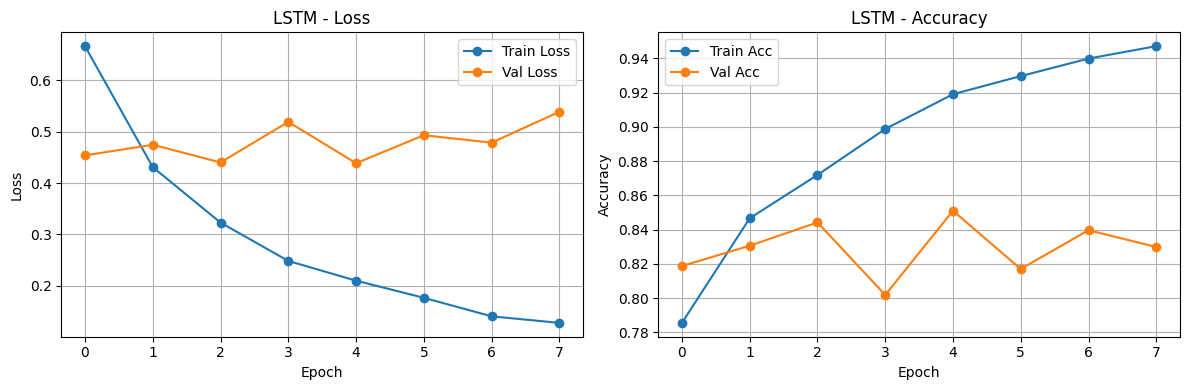

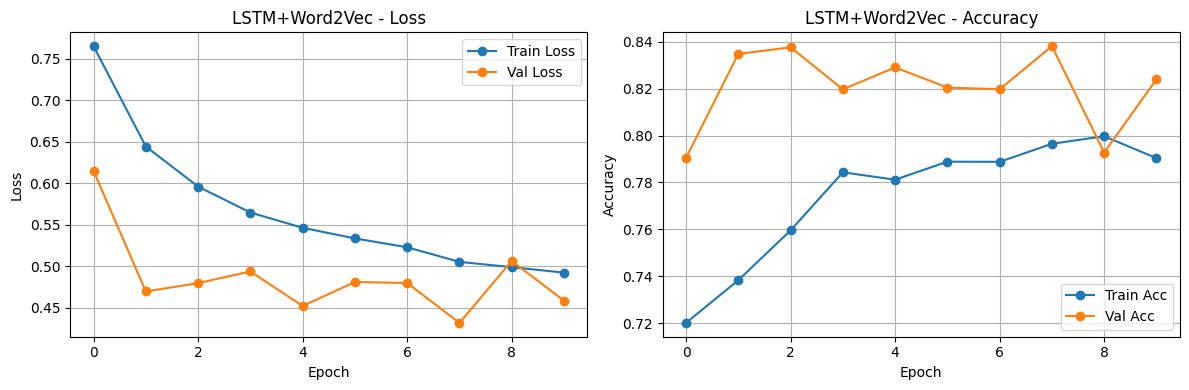

In [47]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='o')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_training_history(history_rnn, "Simple RNN")
plot_training_history(history_lstm, "LSTM")
plot_training_history(history_w2v, "LSTM+Word2Vec")

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Simple RNN
Test Accuracy: 0.8632
                    precision    recall  f1-score   support

       Hate Speech       0.31      0.42      0.36       286
Offensive Language       0.93      0.91      0.92      3838
           Neither       0.82      0.79      0.80       833

          accuracy                           0.86      4957
         macro avg       0.69      0.71      0.69      4957
      weighted avg       0.87      0.86      0.87      4957



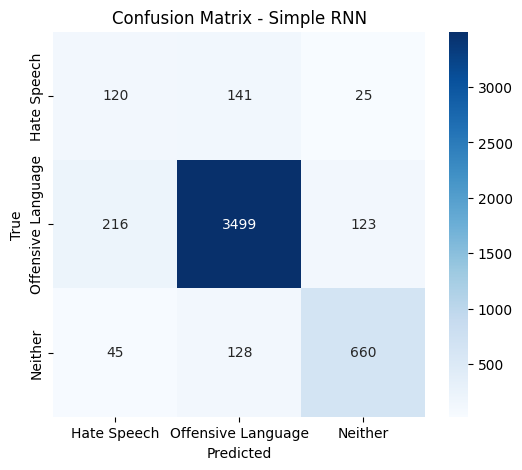

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

LSTM (trainable emb)
Test Accuracy: 0.8517
                    precision    recall  f1-score   support

       Hate Speech       0.32      0.50      0.39       286
Offensive Language       0.94      0.88      0.91      3838
           Neither       0.78      0.84      0.81       833

          accuracy                           0.85      4957
         macro avg       0.68      0.74      0.70      4957
      weighted avg       0.87      0.85      0.86      4957



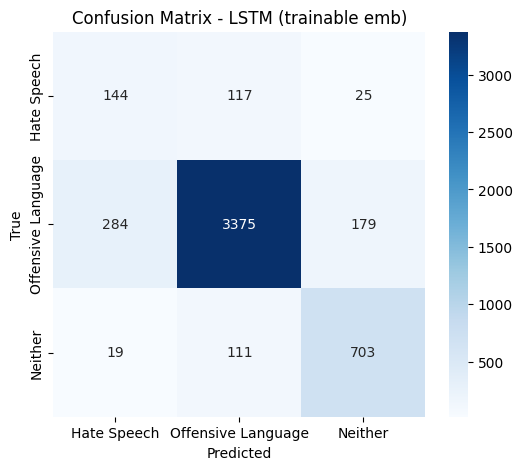

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

LSTM + Word2Vec
Test Accuracy: 0.8418
                    precision    recall  f1-score   support

       Hate Speech       0.32      0.60      0.42       286
Offensive Language       0.96      0.86      0.91      3838
           Neither       0.72      0.83      0.77       833

          accuracy                           0.84      4957
         macro avg       0.67      0.76      0.70      4957
      weighted avg       0.88      0.84      0.86      4957



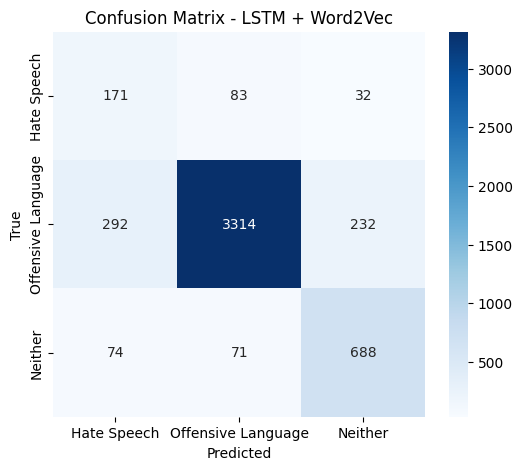

In [43]:
def evaluate_model(model, X_test, y_test_int, y_test_cat, name):
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    print(f"\n{name}")
    print(f"Test Accuracy: {acc:.4f}")
    target_names = ['Hate Speech', 'Offensive Language', 'Neither']
    print(classification_report(y_test_int, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return acc

# Now evaluate all three models (make sure y_test_int is defined)
acc_rnn = evaluate_model(rnn_model, X_test_pad, y_test_int, y_test_cat, "Simple RNN")
acc_lstm = evaluate_model(lstm_model, X_test_pad, y_test_int, y_test_cat, "LSTM (trainable emb)")
acc_w2v = evaluate_model(lstm_w2v, X_test_pad, y_test_int, y_test_cat, "LSTM + Word2Vec")

In [48]:
# Get predictions for test set from best model (e.g., lstm_w2v)
y_pred_probs = lstm_w2v.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test_int)[0]
print(f"Number of misclassified samples: {len(misclassified_idx)}")

# Show 5 examples
class_names = ['Hate Speech', 'Offensive Language', 'Neither']
for i in misclassified_idx[:5]:
    print(f"\nText: {X_test[i]}")
    print(f"True label: {class_names[y_test_int[i]]}")
    print(f"Predicted: {class_names[y_pred[i]]}")
    print(f"Confidence: {np.max(y_pred_probs[i]):.2f}")

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Number of misclassified samples: 784

Text: hardly get sexso opportunity sick present giving pussyand boy generous
True label: Offensive Language
Predicted: Neither
Confidence: 0.42

Text: full nigger
True label: Offensive Language
Predicted: Hate Speech
Confidence: 0.92

Text: least antville cunt
True label: Offensive Language
Predicted: Hate Speech
Confidence: 0.56

Text: would reply red emoji nigger
True label: Offensive Language
Predicted: Hate Speech
Confidence: 0.92

Text: po heart still beatin fast da way dat nigger scream dat microphone felt like da welfare office cut da line
True label: Offensive Language
Predicted: Hate Speech
Confidence: 0.56


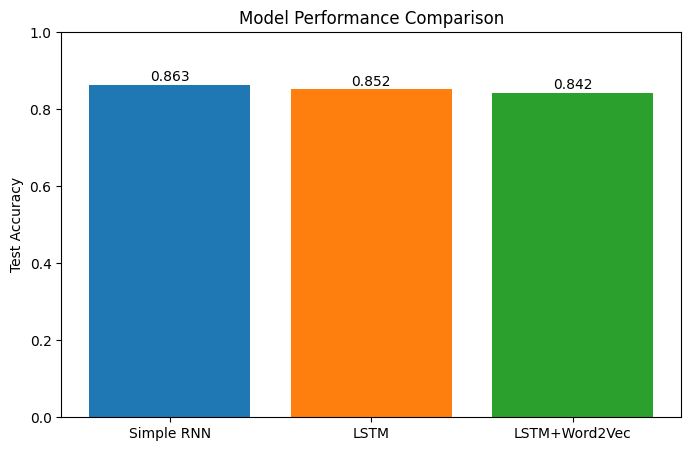

In [44]:
models = ['Simple RNN', 'LSTM', 'LSTM+Word2Vec']
accuracies = [acc_rnn, acc_lstm, acc_w2v]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0,1)
plt.ylabel('Test Accuracy')
plt.title('Model Performance Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center')
plt.show()

In [50]:
# Collect parameter counts
def get_model_params(model):
    return model.count_params()

params_rnn = get_model_params(rnn_model)
params_lstm = get_model_params(lstm_model)
params_w2v = get_model_params(lstm_w2v)

# Accuracies already stored: acc_rnn, acc_lstm, acc_w2v
import pandas as pd
comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM+Word2Vec'],
    'Parameters': [params_rnn, params_lstm, params_w2v],
    'Test Accuracy': [acc_rnn, acc_lstm, acc_w2v]
})
print(comparison_df.to_string(index=False))

        Model  Parameters  Test Accuracy
   Simple RNN     2010755       0.863224
         LSTM     2042435       0.851725
LSTM+Word2Vec     1029635       0.841840


In [45]:
def predict_hate_speech(text, threshold=0.75):
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred_probs = lstm_w2v.predict(padded, verbose=0)[0]
    pred_class = np.argmax(pred_probs)
    confidence = np.max(pred_probs)
    # If confidence below threshold, classify as "Neither"
    if confidence < threshold:
        pred_class = 2
        confidence = 1 - confidence
    class_names = ['Hate Speec', 'Offensive Language', 'Neither']
    return f"Prediction: {class_names[pred_class]} (confidence: {confidence:.2f})"

iface = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(lines=2, placeholder="Enter a comment..."),
    outputs="text",
    title="Hate Speech Detection",
    description="Classifies text as Hate Speech, Offensive Language, or Neither."
)
iface.launch()

* Running on local URL:  http://127.0.0.1:7864
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://bf1e8525943194c861.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
import pandas as pd
print(df['label'].value_counts(normalize=True))


label
offensive language    0.774321
neither               0.167978
hate speec            0.057701
Name: proportion, dtype: float64
